In [3]:
import scipy.stats as st 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [8]:
#cuartiles para obtener 
mu = 0 #media
sigma = 1 ;#desviacion estandar
alpha = 0.95 #nivel de confianza

z_95 = st.norm.ppf(alpha, loc = mu , scale = sigma) #punto de corte asociado al 95% 
print('EL valor de confianza Z  del 95% es : ',z_95)

EL valor de confianza Z  del 95% es :  1.6448536269514722


In [15]:
alpha = 0.975
z_97 = st.norm.ppf(alpha, loc = mu , scale = sigma)
print('EL valor de confianza Z  del 95% es : ',z_97)


EL valor de confianza Z  del 95% es :  1.959963984540054


In [ ]:
print('Cuartiles T students para diferentes grados de libertad (alpha = 0.975)\n')
for dfree in [5,10,50,100,2000]:
    t_value = st.t.ppf(0.95, df=dfree)
    print(f'Grdos de liberta: {dfree}, t-valor: {t_value}')

$$
P\left ( x\leq x_{\alpha }  \right )=\alpha 
$$

In [ ]:
valor_f =st.f.ppf(0.95,dfn=5,dfd=10) 
#el valor de 5 10 representan los grados de libertad 
print(f'Cuantil de F(5,10) para alpha=0.95:{valor_f} ')

Cuantil de F(5,10) para alpha=0.95:3.3258345304130112 


In [50]:
from sklearn.datasets import load_iris
import seaborn as sns
iris = load_iris()
df =pd.DataFrame(data = iris.data, columns = iris.feature_names)
df['species_id'] = iris.target 
df['species'] = df['species_id'].map({i:name for i ,name in enumerate(iris.target_names)})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
x_ic =df['petal length (cm)']
n = len(x_ic)

mean = np.mean(x_ic)
#calculo para la desviacion estandar de la muestra 
std = np.std(x_ic,ddof=1)

#error estandar de la medio (que tanto varia la media de la muestra
SBM = std/np.sqrt(n) 
#si tenemos una desviacion estandar muy grande habra mas insertidumbre 

#Valor critico con un alpha del 0.95
tcrit = st.t.ppf(0.975, df=n-1)

#construccion del intervalo de confianza 
IC = (mean - tcrit*SBM, mean+tcrit*SBM)

print(f'\n IC 95% para la media de petal lenght (cm): {IC}') 


 IC 95% para la media de petal lenght (cm): (np.float64(3.473185370199511), np.float64(4.04281462980049))


Matriz de correlacion de Pearson 
                    sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


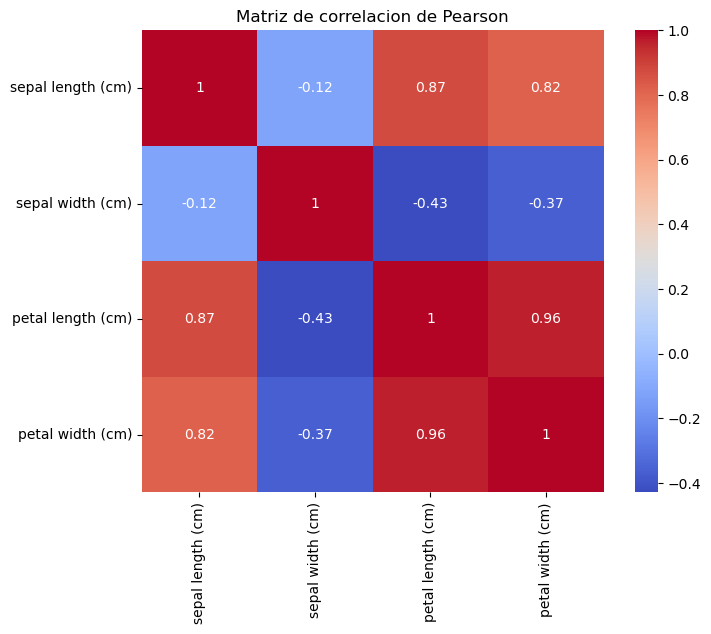

In [31]:
# correlacion medida estadistica que indica el grado de relacion entre dos varibles
# la mas usada es la correlacion de pearson 

features = iris.feature_names
corr_p = df[features].corr(method = 'pearson')
print('Matriz de correlacion de Pearson \n',corr_p)
plt.figure(figsize=(8,6))

sns.heatmap(corr_p , annot = True, cmap = 'coolwarm',square = True)
plt.title('Matriz de correlacion de Pearson')
plt.show()


Matriz de correlacion de spearman 
                    sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.166778           0.881898   
sepal width (cm)           -0.166778          1.000000          -0.309635   
petal length (cm)           0.881898         -0.309635           1.000000   
petal width (cm)            0.834289         -0.289032           0.937667   

                   petal width (cm)  
sepal length (cm)          0.834289  
sepal width (cm)          -0.289032  
petal length (cm)          0.937667  
petal width (cm)           1.000000  


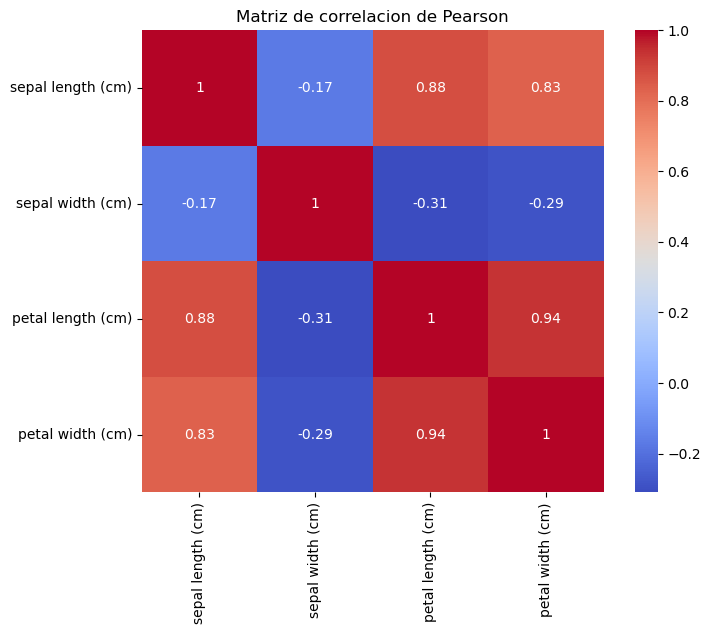

In [ ]:
#correlacion de sperman, relacion no  lineal entre las dos variables
# se utilza con valores atipicos 

corr_s = df[features].corr(method = 'spearman')
print('Matriz de correlacion de spearman \n',corr_s)
plt.figure(figsize=(8,6))

sns.heatmap(corr_s , annot = True, cmap = 'coolwarm',square = True)
plt.title('Matriz de correlacion de Spearman')
plt.show()

In [ ]:
#corelacion de kendall, esta es menos cencible a empates, se utiliza en datos ordinales 
# o con datos de varios elementos de datos repetidos 

Matriz de correlacion de kendall 
                    sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.076997           0.718516   
sepal width (cm)           -0.076997          1.000000          -0.185994   
petal length (cm)           0.718516         -0.185994           1.000000   
petal width (cm)            0.655309         -0.157126           0.806891   

                   petal width (cm)  
sepal length (cm)          0.655309  
sepal width (cm)          -0.157126  
petal length (cm)          0.806891  
petal width (cm)           1.000000  


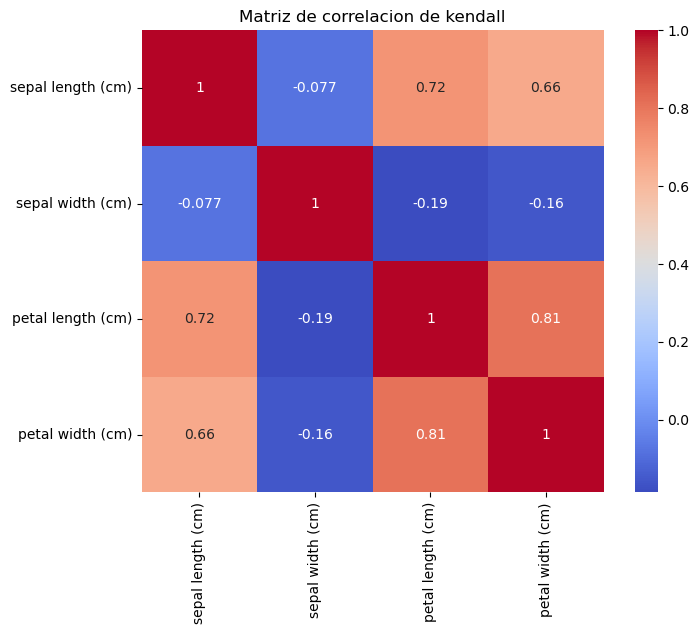

In [34]:
corr_k = df[features].corr(method = 'kendall')
print('Matriz de correlacion de kendall \n',corr_k)
plt.figure(figsize=(8,6))

sns.heatmap(corr_k , annot = True, cmap = 'coolwarm',square = True)
plt.title('Matriz de correlacion de kendall')
plt.show()

Ena fabrica de bombillas la probabilidad de que una bombilla sea defectuosa es del 2%. Si se seleccionan 20 bombillas al zar,
¿cual es la probabilidad en encintrar 2 bombillas defectuosas? Ademas, calcularemos la media y la varianza de la cantidad de bombillas defectuosas 

In [40]:
import math 
from scipy.stats import binom 
#n numero de bombillas 
#p probbilidad de que una bombilla sea defectuosa 
#K numero de bombillas a la cual le queremos calcular la prbabilidad  
n = 20
p = 0.02
k = 2

prob = binom.pmf(k,n,p) #funion de probabilidad de una variable discreta pmf
media = n*p
varianza = n*p*(1-p)

print(f'Probabilidad de que exactamente 2 de 20 bombillas sean defectuoss : {prob}')
print(f'Media :{media}')
print(f'Varianza {varianza}')

Probabilidad de que exactamente 2 de 20 bombillas sean defectuoss : 0.052830285145134465
Media :0.4
Varianza 0.392


In [46]:
#Ahora para n = 100

n_aumentada = 100
prob = binom.pmf(k,n_aumentada,p).round(3) #funion de probabilidad de una variable discreta pmf
media_aumentada = (n_aumentada)*p
varianza_aumentada = (n_aumentada)*p*(1-p)

print(f'Probabilidad de que exactamente 2 de 100 bombillas sean defectuoss : {prob}')
print(f'Media :{media}')
print(f'Varianza {varianza}')

Probabilidad de que exactamente 2 de 100 bombillas sean defectuoss : 0.273
Media :2.0
Varianza 1.96


In [ ]:
from scipy.stats import norm
#definicion de limite inferior y superior P(1.5 < X < 2.5) 
x_infer = 1.5
x_super = 2.5 
prob_normal = norm.cdf(x_super,media_aumentada,math.sqrt(varianza_aumentada)) - norm.cdf(x_infer,media_aumentada, math.sqrt(varianza_aumentada))

print('Probabilidad Normal: ',prob_normal)



Probabilidad norma 0.27901513809832923


$H_{0}$ = la especie y la categoria del sapalo son independientes


$H_{1}$ = la especie y la categoria del sepalo No son independientes 

In [ ]:
#prueba de la chi-cuadrada 
df['sepal_cat'] = pd.qcut(df['sepal length (cm)'], q = 3, labels=['corto','medio','Largo'])
cont = pd.crosstab(df['species'],df['sepal_cat'])
chi2, p_valor,dof,expected = st.chi2_contingency(cont) 

print('\n Resultados del test de chi-cuadrada: \n')
print('Tabla\n',cont)
print(f'\nchi-cuadrada: {chi2}\n p-Valor{p_valor} \n grados de libertad {dof}')


 Resultados del test de chi-cuadrada: 

Tabla
 sepal_cat   corto  medio  Largo
species                        
setosa         45      5      0
versicolor      6     33     11
virginica       1     18     31

chi-cuadrada: 123.28296703296702
 p-Valor1.062443605236252e-25 
 grados de libertad 4


$H_{0}$ = las medias de la longuitud del sepalo de setosa y virginica son iguales 

$H_{1}$ = las medidas son diferentes 

In [66]:
# prueba T 

setosa = df[df.species == 'setosa']['sepal length (cm)']
virginica = df[df.species == 'virginica']['sepal length (cm)']

tstat, p_valor = st.ttest_ind(setosa,virginica,equal_var=False) 
print('t = ',tstat,'\n p-valor = ',p_valor)

t =  -15.386195820079404 
 p-valor =  3.9668672709859296e-25


$H_{0}$ = Todas las especies tienen la misma media de longitud del petalo

$H_{1}$ = Al menos una de las medias es diferente 

In [75]:
#Prueba de Anova
S1 = df[df.species == 'setosa']['petal length (cm)']
S2 = df[df.species == 'versicolor']['petal length (cm)']
S3 = df[df.species == 'virginica']['petal length (cm)']

Fstat, p_valor = st.f_oneway(S1,S2,S3)

print(' t = ', Fstat,'\np-valor = ',p_valor)

 t =  1180.161182252981 
p-valor =  2.8567766109615584e-91
